In [1]:
import numpy as np 
import torch
from preprocess_cnn_training import *

In [6]:
# preprocess RAVDESS for CNN pre-training purposes

data_dir = '../../data/audio/cnn_training_data'  # Path to the root audio folder
features_tensor, labels_tensor = preprocess_audio_data_to_tensor(data_dir)
print("Extracted tensor shape:", features_tensor.shape)  # Expected shape: [number of recordings, 180]

# If you want to save the tensor for later usage
torch.save(features_tensor, '../../data/audio/audio_features_tensor.pt')
torch.save(labels_tensor, '../../data/audio/audio_labels_tensor.pt')

Processing Actor_02:  18%|█▊        | 11/60 [00:00<00:00, 54.79it/s]


KeyboardInterrupt: 

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset, DataLoader
from emotion_cnn import EmotionCNN  # Assuming EmotionCNN is your model class

# Load data and labels
data_path = '../../data/audio/audio_features_tensor.pt'  
labels_path = '../../data/audio/audio_labels_tensor.pt'  
features_tensor = torch.load(data_path)
labels_tensor = torch.load(labels_path)[:,2] - 1

# Hyperparameters
num_classes = 8  # Adjust to the actual number of classes
num_epochs = 300
batch_size = 100
learning_rate = 0.0001
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
from emotion_cnn import EmotionCNN  
model = EmotionCNN(num_classes)
model

EmotionCNN(
  (conv1): Conv1d(1, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(256, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=8, stride=8, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Linear(in_features=1408, out_features=8, bias=True)
)

In [ ]:

# # Prepare dataset
# dataset = TensorDataset(features_tensor, labels_tensor)

# # Initialize KFold cross-validation
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# fold_results = []

# for fold, (train_index, val_index) in enumerate(kf.split(dataset)):
#     print(f"Fold {fold + 1}")

#     # Create data loaders for the current fold
#     train_subset = torch.utils.data.Subset(dataset, train_index)
#     val_subset = torch.utils.data.Subset(dataset, val_index)
#     train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
#     val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

#     # Initialize the model, optimizer, and loss function
#     model = EmotionCNN(num_classes).to(device)
#     optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
#     # Define the learning rate scheduler
#     scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)  # T_max is the max epoch count
#     criterion = nn.CrossEntropyLoss()

#     # Training loop for this fold
#     for epoch in range(num_epochs):
#         model.train()
#         train_loss = 0.0
#         for features, labels in train_loader:
#             features, labels = features.view(-1, 1, 180).to(device), labels.to(device).long()

#             # print(labels.shape)
#             # Forward pass
#             outputs = model(features)
#             loss = criterion(outputs, labels)

#             # Backward and optimize
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
            
#         scheduler.step()

#         avg_train_loss = train_loss / len(train_loader)
#         print(f"Fold {fold + 1}, Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}")

#     # Validation loop for this fold
#     model.eval()
#     correct_predictions = 0
#     total_samples = 0
#     val_loss = 0.0
#     with torch.no_grad():
#         for features, labels in val_loader:
#             features, labels = features.view(-1, 1, 180).to(device), labels.to(device).long()
#             # print(features.shape)
#             outputs = model(features)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()

#             _, predicted = torch.max(outputs, dim=1)
#             correct_predictions += (predicted == labels).sum().item()
#             total_samples += labels.size(0)

#     avg_val_loss = val_loss / len(val_loader)
#     accuracy = correct_predictions / total_samples
#     print(f"Fold {fold + 1}, Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}")

#     # Save results for this fold
#     fold_results.append({'fold': fold + 1, 'val_loss': avg_val_loss, 'accuracy': accuracy})

# # Calculate the average accuracy and loss across all folds
# avg_accuracy = sum([result['accuracy'] for result in fold_results]) / len(fold_results)
# avg_val_loss = sum([result['val_loss'] for result in fold_results]) / len(fold_results)
# print(f"\n5-Fold Cross-Validation Results: Average Accuracy: {avg_accuracy:.4f}, Average Validation Loss: {avg_val_loss:.4f}")


Fold 1


/mnt/hd1/jwsong/.conda/envs/finEm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fold 1, Epoch [1/300], Training Loss: 3.9246
Fold 1, Epoch [2/300], Training Loss: 2.2714
Fold 1, Epoch [3/300], Training Loss: 2.1381
Fold 1, Epoch [4/300], Training Loss: 1.9997
Fold 1, Epoch [5/300], Training Loss: 2.0317
Fold 1, Epoch [6/300], Training Loss: 2.0081
Fold 1, Epoch [7/300], Training Loss: 2.0384
Fold 1, Epoch [8/300], Training Loss: 1.9696
Fold 1, Epoch [9/300], Training Loss: 1.9414
Fold 1, Epoch [10/300], Training Loss: 1.9255
Fold 1, Epoch [11/300], Training Loss: 1.9349
Fold 1, Epoch [12/300], Training Loss: 1.8798
Fold 1, Epoch [13/300], Training Loss: 1.9876
Fold 1, Epoch [14/300], Training Loss: 1.9154
Fold 1, Epoch [15/300], Training Loss: 1.8863
Fold 1, Epoch [16/300], Training Loss: 1.8717
Fold 1, Epoch [17/300], Training Loss: 1.8317
Fold 1, Epoch [18/300], Training Loss: 1.8069
Fold 1, Epoch [19/300], Training Loss: 1.8858
Fold 1, Epoch [20/300], Training Loss: 1.8605
Fold 1, Epoch [21/300], Training Loss: 1.8087
Fold 1, Epoch [22/300], Training Loss: 1.81

In [4]:
fold_results

[{'fold': 1, 'val_loss': 1.595062255859375, 'accuracy': 0.6666666666666666},
 {'fold': 2, 'val_loss': 1.8236773411432903, 'accuracy': 0.6319444444444444},
 {'fold': 3, 'val_loss': 1.6746025482813518, 'accuracy': 0.6458333333333334},
 {'fold': 4, 'val_loss': 0.8543254335721334, 'accuracy': 0.7291666666666666},
 {'fold': 5, 'val_loss': 1.9089686473210652, 'accuracy': 0.6215277777777778}]

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
from emotion_cnn import EmotionCNN  # Ensure this is the correct import for your model

# Prepare dataset
dataset = TensorDataset(features_tensor, labels_tensor)

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
fold_accuracies = []  # Store accuracies for each fold

for fold, (train_index, val_index) in enumerate(kf.split(dataset)):
    print(f"Fold {fold + 1}")

    # Create data loaders for the current fold
    train_subset = torch.utils.data.Subset(dataset, train_index)
    val_subset = torch.utils.data.Subset(dataset, val_index)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Initialize the model, optimizer, and loss function
    model = EmotionCNN(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Define the learning rate scheduler
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    # Track training accuracy for this fold
    epoch_accuracies = []

    # Training loop for this fold
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for features, labels in train_loader:
            features, labels = features.view(-1, 1, 180).to(device), labels.to(device).long()

            # Forward pass
            outputs = model(features)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Calculate accuracy for training data in this epoch
            _, predicted = torch.max(outputs, dim=1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        # Step the scheduler and calculate epoch accuracy
        # scheduler.step()
        avg_train_loss = train_loss / len(train_loader)
        epoch_accuracy = correct_predictions / total_samples
        epoch_accuracies.append(epoch_accuracy)

        print(f"Fold {fold + 1}, Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {epoch_accuracy:.4f}")

    # Save accuracy for this fold to plot later
    fold_accuracies.append(epoch_accuracies)

    # Validation loop for this fold
    model.eval()
    correct_predictions = 0
    total_samples = 0
    val_loss = 0.0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.view(-1, 1, 180).to(device), labels.to(device).long()
            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)
            

    avg_val_loss = val_loss / len(val_loader)
    accuracy = correct_predictions / total_samples
    print(f"Fold {fold + 1}, Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}")

    # Save results for this fold
    fold_results.append({'fold': fold + 1, 'val_loss': avg_val_loss, 'accuracy': accuracy})

# # Plotting the training accuracy for each fold
# plt.figure(figsize=(12, 8))
# for fold, accuracies in enumerate(fold_accuracies):
#     plt.plot(range(1, num_epochs + 1), accuracies, label=f'Fold {fold + 1}')
# plt.xlabel('Epoch')
# plt.ylabel('Training Accuracy')
# plt.title('Training Accuracy Across Epochs for Each Fold')
# plt.legend()
# plt.show()

# Calculate the average accuracy and loss across all folds
avg_accuracy = sum([result['accuracy'] for result in fold_results]) / len(fold_results)
avg_val_loss = sum([result['val_loss'] for result in fold_results]) / len(fold_results)
print(f"\n5-Fold Cross-Validation Results: Average Accuracy: {avg_accuracy:.4f}, Average Validation Loss: {avg_val_loss:.4f}")


Fold 1


/mnt/hd1/jwsong/.conda/envs/finEm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fold 1, Epoch [1/1000], Training Loss: 2.5563, Training Accuracy: 0.1207
Fold 1, Epoch [2/1000], Training Loss: 2.1029, Training Accuracy: 0.1745
Fold 1, Epoch [3/1000], Training Loss: 2.0165, Training Accuracy: 0.1884
Fold 1, Epoch [4/1000], Training Loss: 2.0370, Training Accuracy: 0.2092
Fold 1, Epoch [5/1000], Training Loss: 1.9689, Training Accuracy: 0.2344
Fold 1, Epoch [6/1000], Training Loss: 1.9201, Training Accuracy: 0.2509
Fold 1, Epoch [7/1000], Training Loss: 1.9055, Training Accuracy: 0.2561
Fold 1, Epoch [8/1000], Training Loss: 1.9160, Training Accuracy: 0.2578
Fold 1, Epoch [9/1000], Training Loss: 1.9315, Training Accuracy: 0.2448
Fold 1, Epoch [10/1000], Training Loss: 1.8551, Training Accuracy: 0.2648
Fold 1, Epoch [11/1000], Training Loss: 1.8383, Training Accuracy: 0.2865
Fold 1, Epoch [12/1000], Training Loss: 1.8472, Training Accuracy: 0.2708
Fold 1, Epoch [13/1000], Training Loss: 1.8636, Training Accuracy: 0.2743
Fold 1, Epoch [14/1000], Training Loss: 1.8445,

KeyboardInterrupt: 

Fold 1
Fold 1, Epoch [1/300], Training Loss: 2.4411, Training Accuracy: 0.1372, Validation Loss: 2.0502, Validation Accuracy: 0.1944
Fold 1, Epoch [2/300], Training Loss: 2.0930, Training Accuracy: 0.1814, Validation Loss: 1.9621, Validation Accuracy: 0.2049
Fold 1, Epoch [3/300], Training Loss: 2.0215, Training Accuracy: 0.1927, Validation Loss: 1.9396, Validation Accuracy: 0.2257
Fold 1, Epoch [4/300], Training Loss: 1.9738, Training Accuracy: 0.2144, Validation Loss: 1.8814, Validation Accuracy: 0.2882
Fold 1, Epoch [5/300], Training Loss: 1.9256, Training Accuracy: 0.2517, Validation Loss: 1.8450, Validation Accuracy: 0.2882
Fold 1, Epoch [6/300], Training Loss: 1.9351, Training Accuracy: 0.2569, Validation Loss: 1.8475, Validation Accuracy: 0.2361
Fold 1, Epoch [7/300], Training Loss: 1.9437, Training Accuracy: 0.2405, Validation Loss: 1.9245, Validation Accuracy: 0.2500
Fold 1, Epoch [8/300], Training Loss: 1.9324, Training Accuracy: 0.2483, Validation Loss: 1.8526, Validation Ac

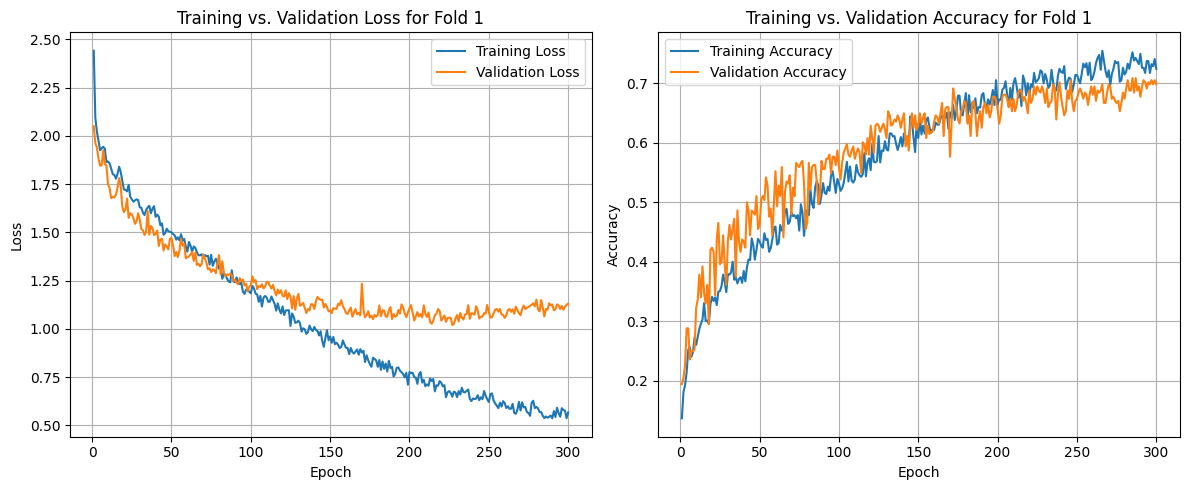

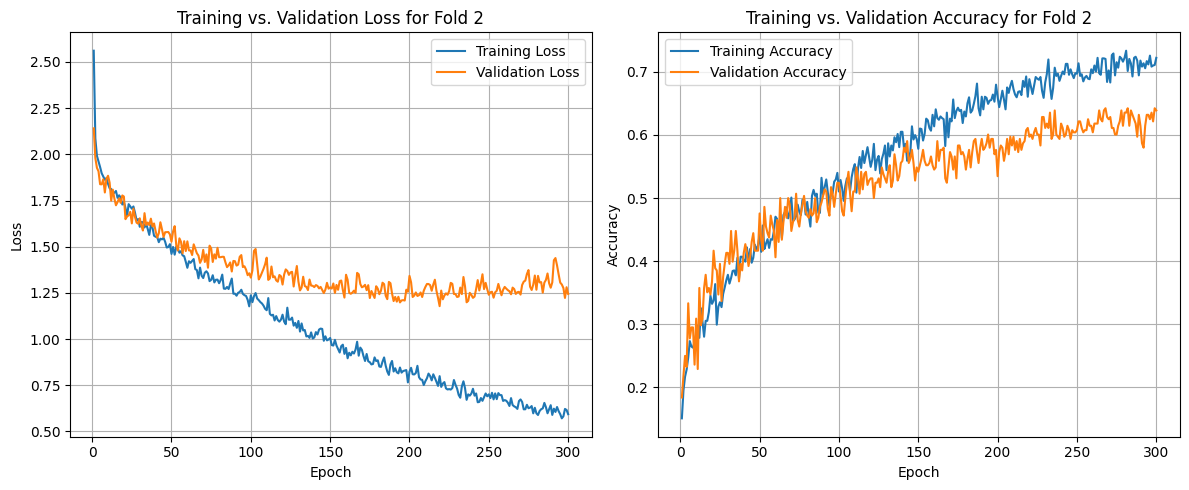

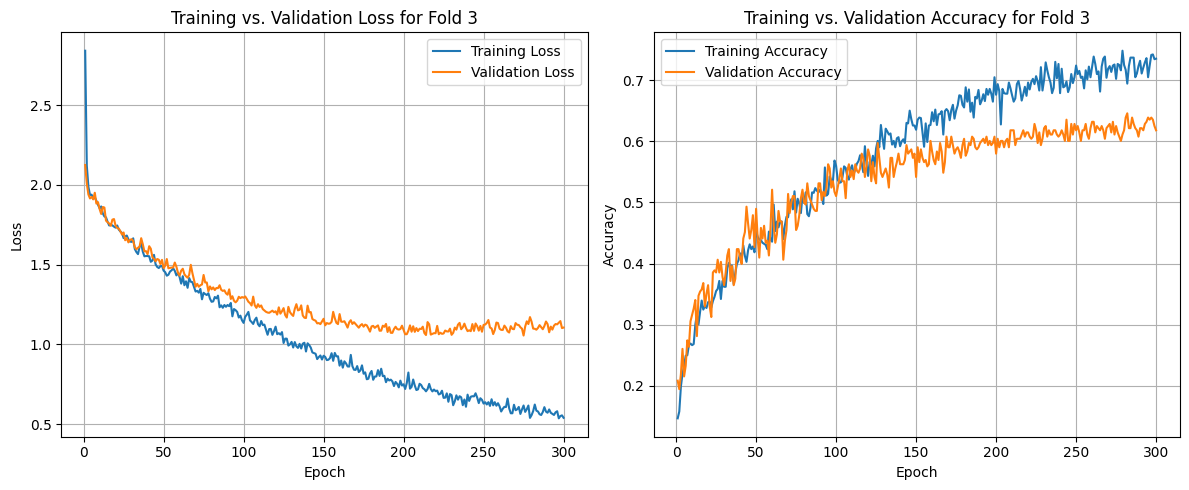

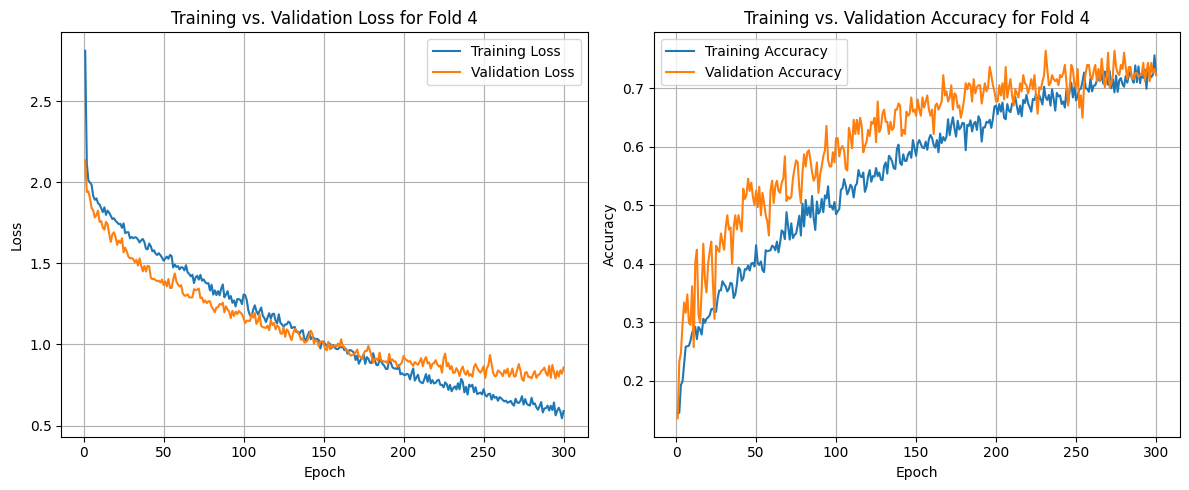

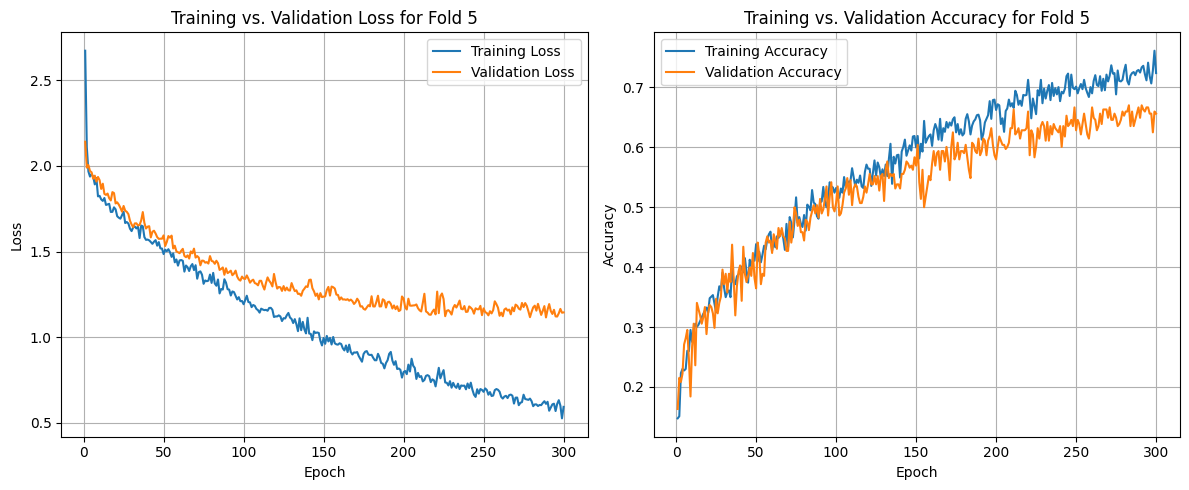

ZeroDivisionError: division by zero

In [9]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
from emotion_cnn import EmotionCNN  # Ensure this is the correct import for your model

# Prepare dataset
dataset = TensorDataset(features_tensor, labels_tensor)

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

# Track loss and accuracy for plotting
train_loss_per_fold = []
val_loss_per_fold = []
train_accuracy_per_fold = []
val_accuracy_per_fold = []

for fold, (train_index, val_index) in enumerate(kf.split(dataset)):
    print(f"Fold {fold + 1}")

    # Create data loaders for the current fold
    train_subset = torch.utils.data.Subset(dataset, train_index)
    val_subset = torch.utils.data.Subset(dataset, val_index)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Initialize the model, optimizer, and loss function
    model = EmotionCNN(num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Track losses and accuracies for this fold
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    # Training loop for this fold
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for features, labels in train_loader:
            features, labels = features.view(-1, 1, 180).to(device), labels.to(device).long()

            # Forward pass
            outputs = model(features)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Calculate training accuracy for this batch
            _, predicted = torch.max(outputs, dim=1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        # Calculate average training loss and accuracy for this epoch
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_accuracy = correct_predictions / total_samples
        train_accuracies.append(train_accuracy)

        # Validation loop for this epoch
        model.eval()
        val_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.view(-1, 1, 180).to(device), labels.to(device).long()
                outputs = model(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Calculate validation accuracy
                _, predicted = torch.max(outputs, dim=1)
                correct_predictions += (predicted == labels).sum().item()
                total_samples += labels.size(0)

        # Calculate average validation loss and accuracy for this epoch
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accuracy = correct_predictions / total_samples
        val_accuracies.append(val_accuracy)

        print(f"Fold {fold + 1}, Epoch [{epoch + 1}/{num_epochs}], "
              f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}, "
              f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    # Append losses and accuracies for this fold to the lists
    train_loss_per_fold.append(train_losses)
    val_loss_per_fold.append(val_losses)
    train_accuracy_per_fold.append(train_accuracies)
    val_accuracy_per_fold.append(val_accuracies)

# Plot training vs. validation loss and accuracy for each fold
for fold in range(5):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_loss_per_fold[fold], label="Training Loss")
    plt.plot(range(1, num_epochs + 1), val_loss_per_fold[fold], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs. Validation Loss for Fold {fold + 1}")
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_accuracy_per_fold[fold], label="Training Accuracy")
    plt.plot(range(1, num_epochs + 1), val_accuracy_per_fold[fold], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training vs. Validation Accuracy for Fold {fold + 1}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Calculate the average accuracy and loss across all folds
avg_accuracy = sum([result['accuracy'] for result in fold_results]) / len(fold_results)
avg_val_loss = sum([result['val_loss'] for result in fold_results]) / len(fold_results)
print(f"\n5-Fold Cross-Validation Results: Average Accuracy: {avg_accuracy:.4f}, Average Validation Loss: {avg_val_loss:.4f}")


In [15]:
val_loss_per_fold

[[2.050163189570109,
  1.9621010621388753,
  1.9395864804585774,
  1.881353457768758,
  1.845015009244283,
  1.8474775950113933,
  1.9245345989863079,
  1.8526064554850261,
  1.8470490376154582,
  1.7489635547002156,
  1.7281523545583088,
  1.6773009300231934,
  1.6835128863652546,
  1.6808976729710896,
  1.6958730220794678,
  1.7320882081985474,
  1.780837893486023,
  1.7394652366638184,
  1.6325729290644329,
  1.604436953862508,
  1.6184498469034831,
  1.674999435742696,
  1.5751406749089558,
  1.5987943013509114,
  1.5925482511520386,
  1.5746559699376423,
  1.5437297026316326,
  1.5574886004130046,
  1.5992309252421062,
  1.5644224484761555,
  1.5166683594385784,
  1.510282317797343,
  1.4859780470530193,
  1.5034021933873494,
  1.610629955927531,
  1.4873202244440715,
  1.5324279069900513,
  1.5228644609451294,
  1.4853460788726807,
  1.4917880296707153,
  1.5086423953374226,
  1.4293843507766724,
  1.461976408958435,
  1.4661637544631958,
  1.4055521090825398,
  1.437178611755371

In [16]:
# train_loss_per_fold = []
# val_loss_per_fold = []
# train_accuracy_per_fold = []
# val_accuracy_per_fold = []

fold_results = []
for i in range(0, 5):
    temp = {
        'fold': i+1, 
        'val_loss': np.mean(val_loss_per_fold[i]), 
        'val_acc': np.mean(val_accuracy_per_fold[i]),
        'train_loss': np.mean(train_loss_per_fold[i]),
        'train_acc': np.mean(train_accuracy_per_fold[i])
    }
    fold_results.append(temp)

In [17]:
fold_results

[{'fold': 1,
  'val_loss': 1.2296984861294429,
  'val_acc': 0.5891550925925926,
  'train_loss': 1.0404922421359353,
  'train_acc': 0.578990162037037},
 {'fold': 2,
  'val_loss': 1.383882549736235,
  'val_acc': 0.526423611111111,
  'train_loss': 1.0703539118336307,
  'train_acc': 0.5680121527777778},
 {'fold': 3,
  'val_loss': 1.271913105580542,
  'val_acc': 0.5376388888888889,
  'train_loss': 1.033534437318643,
  'train_acc': 0.5800868055555556},
 {'fold': 4,
  'val_loss': 1.1017805425988305,
  'val_acc': 0.6164351851851851,
  'train_loss': 1.0961955501884222,
  'train_acc': 0.5592939814814816},
 {'fold': 5,
  'val_loss': 1.3407957563135358,
  'val_acc': 0.5326041666666667,
  'train_loss': 1.0769379548066194,
  'train_acc': 0.5680613425925927}]

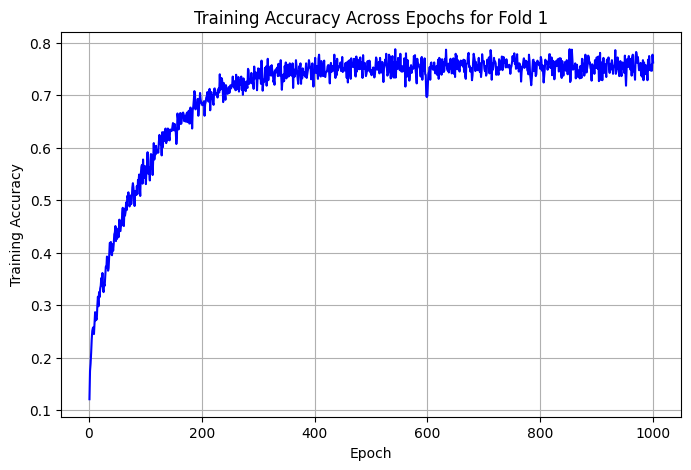

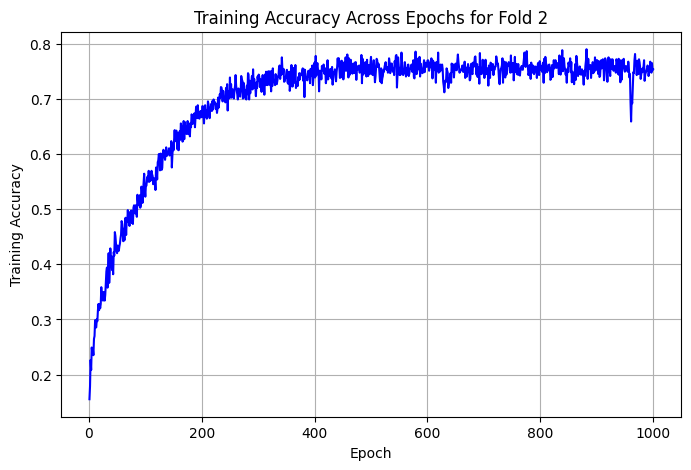

In [5]:

# Plotting the training accuracy for each fold in separate graphs
for fold, accuracies in enumerate(fold_accuracies):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), accuracies, linestyle='-', color='b')
    plt.xlabel('Epoch')
    plt.ylabel('Training Accuracy')
    plt.title(f'Training Accuracy Across Epochs for Fold {fold + 1}')
    plt.grid(True)
    plt.show()